## Problem Statement

### Title: Lung Cancer Risk Prediction using Machine Learning

Lung cancer is one of the leading causes of death worldwide. Early detection of lung cancer can significantly improve treatment success and survival rates. However, identifying individuals at high risk is difficult because lung cancer depends on multiple factors such as smoking habits, pollution exposure, genetics, lifestyle, and health conditions.

The objective of this project is to develop a Machine Learning model that predicts the risk level of lung cancer (Low, Medium, or High) based on different health and lifestyle features.

The system analyzes patient-related information such as:

Age

Gender

Smoking habits

Air pollution exposure

Alcohol consumption

Genetic risk

Obesity

Diet

Chest pain

Fatigue

Other medical indicators

Using these features, different machine learning algorithms are trained and compared to identify the most accurate model. The final model can help in early risk assessment of lung cancer patients.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import joblib

## This cell imports all the libraries, which is used to work with datasets in this project.

pandas → used for data handling and analysis

seaborn → used for statistical data visualization

matplotlib → used to create graphs and plots

train_test_split → used to divide dataset into training and testing sets

LogisticRegression → machine learning algorithm for classification

accuracy_score → calculates model accuracy

classification_report → shows precision, recall, and F1-score

confusion_matrix → evaluates prediction performance

## Dataset 

Loads the dataset from a CSV file

Stores the dataset in dataframe df

Used for further data analysis and ML processing

In [2]:
df = pd.read_csv("lung_cancer_dataset_balanced.csv")

In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (25000, 24)


This shows the size of the dataset.

df.shape returns two numbers:

Number of rows → total patient records

Number of columns → total features

In [4]:
# Columns
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Age', 'Gender', 'Air_Pollution', 'Alcohol_use', 'Genetic_Risk', 'Chronic_Lung_Disease', 'Balanced_Diet', 'Obesity', 'Smoking', 'Passive_Smoker', 'Chest_Pain', 'Coughing_of_Blood', 'Fatigue', 'Weight_Loss', 'Shortness_of_Breath', 'Wheezing', 'Swallowing_Difficulty', 'Clubbing_of_Finger_Nails', 'Frequent_Cold', 'Dry_Cough', 'Dust_Allergy', 'Occupational_Hazards', 'Snoring', 'Level']


This prints the names of all columns in the dataset.

These columns represent different health and lifestyle factors related to lung cancer risk.

In [5]:
# Target variable
target = "Level"
print("\nTarget Variable:", target)


Target Variable: Level


This defines the target variable.

Target variable = what the model will predict.

Which represents lung cancer risk level.

values are:

Low

Medium

High

In [6]:
# Numerical and categorical features
categorical_features = ["Gender", "Level"]
numerical_features = [col for col in df.columns if col not in categorical_features]


This separates the dataset into two types of features.

Categorical Features

These contain categories or labels.

Example:

Gender

Level

Numerical Features

These contain numbers or scores.

Example:

Age

Smoking

Air Pollution

Alcohol Use

This separation helps during data preprocessing and modeling.

In [7]:
print("\nCategorical Features:", categorical_features)
print("\nNumerical Features:", numerical_features)


Categorical Features: ['Gender', 'Level']

Numerical Features: ['Age', 'Air_Pollution', 'Alcohol_use', 'Genetic_Risk', 'Chronic_Lung_Disease', 'Balanced_Diet', 'Obesity', 'Smoking', 'Passive_Smoker', 'Chest_Pain', 'Coughing_of_Blood', 'Fatigue', 'Weight_Loss', 'Shortness_of_Breath', 'Wheezing', 'Swallowing_Difficulty', 'Clubbing_of_Finger_Nails', 'Frequent_Cold', 'Dry_Cough', 'Dust_Allergy', 'Occupational_Hazards', 'Snoring']


This prints the lists created in the previous step.

It helps verify that the features are correctly classified as categorical or numerical.

## Data Cleaning

Data cleaning means:

removing duplicates

fixing errors

checking missing values

In [8]:
# Duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 52


This checks how many duplicate rows exist in the dataset.

Duplicate data can create bias in machine learning models, so it must be removed.

In [9]:
# Remove duplicates
df = df.drop_duplicates()

This removes all duplicate rows from the dataset.

Now each row represents a unique patient record.

In [10]:
# check Duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


This checks duplicates again to confirm that all duplicates were removed.

In [11]:
print("New Shape:", df.shape)

New Shape: (24948, 24)


This shows the new dataset size after removing duplicates.

Rows may decrease if duplicates were present.

In [12]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                         0
Gender                      0
Air_Pollution               0
Alcohol_use                 0
Genetic_Risk                0
Chronic_Lung_Disease        0
Balanced_Diet               0
Obesity                     0
Smoking                     0
Passive_Smoker              0
Chest_Pain                  0
Coughing_of_Blood           0
Fatigue                     0
Weight_Loss                 0
Shortness_of_Breath         0
Wheezing                    0
Swallowing_Difficulty       0
Clubbing_of_Finger_Nails    0
Frequent_Cold               0
Dry_Cough                   0
Dust_Allergy                0
Occupational_Hazards        0
Snoring                     0
Level                       0
dtype: int64


This checks for missing values in each column.

Missing values can affect model accuracy.

In [13]:
#Fix negative zeros if present
df = df.replace(-0.0, 0)

Sometimes datasets contain negative zero values (-0.0) due to data generation issues.

This line converts -0.0 to normal 0 to keep the dataset clean.

## Exploratory Data Analysis (EDA)

EDA helps understand:

patterns

relationships

distributions

in the dataset.

In [14]:
df.head(10)

,Age,Gender,Air_Pollution,Alcohol_use,Genetic_Risk,Chronic_Lung_Disease,Balanced_Diet,Obesity,Smoking,Passive_Smoker,...,Shortness_of_Breath,Wheezing,Swallowing_Difficulty,Clubbing_of_Finger_Nails,Frequent_Cold,Dry_Cough,Dust_Allergy,Occupational_Hazards,Snoring,Level
0,40.0,1,5.0,2.0,6.0,4.0,4.0,6.0,4.0,10.0,...,7.0,5.0,4.0,3.0,6.0,2.0,5.0,6.0,3.0,High
1,87.0,1,3.0,6.0,1.0,4.0,4.0,8.0,0.0,1.0,...,4.0,3.0,4.0,0.0,5.0,5.0,3.0,0.0,6.0,Low
2,21.0,0,7.0,8.0,5.0,5.0,7.0,4.0,0.0,4.0,...,6.0,2.0,1.0,0.0,8.0,3.0,4.0,9.0,5.0,Medium
3,57.0,0,7.0,4.0,6.0,3.0,7.0,3.0,3.0,2.0,...,3.0,2.0,2.0,2.0,2.0,5.0,7.0,1.0,2.0,Medium
4,27.0,1,7.0,2.0,6.0,3.0,3.0,10.0,3.0,1.0,...,7.0,4.0,4.0,2.0,3.0,0.0,1.0,5.0,2.0,Medium
5,34.0,1,7.0,8.0,4.0,4.0,3.0,10.0,6.0,7.0,...,7.0,8.0,2.0,4.0,2.0,2.0,6.0,4.0,10.0,High
6,36.0,1,7.0,2.0,7.0,8.0,2.0,4.0,3.0,4.0,...,8.0,4.0,4.0,4.0,4.0,2.0,2.0,1.0,2.0,High
7,64.0,1,7.0,4.0,3.0,4.0,3.0,7.0,3.0,4.0,...,6.0,3.0,3.0,6.0,6.0,3.0,7.0,6.0,5.0,Medium
8,23.0,1,4.0,9.0,7.0,8.0,4.0,3.0,8.0,10.0,...,10.0,6.0,7.0,0.0,5.0,7.0,2.0,2.0,3.0,High
9,19.0,1,9.0,4.0,6.0,3.0,3.0,9.0,3.0,2.0,...,8.0,4.0,4.0,2.0,4.0,0.0,4.0,5.0,8.0,Medium


This displays the first 10 rows of the dataset.

It helps verify:

columns

data format

values

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24948 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       24948 non-null  float64
 1   Gender                    24948 non-null  int64  
 2   Air_Pollution             24948 non-null  float64
 3   Alcohol_use               24948 non-null  float64
 4   Genetic_Risk              24948 non-null  float64
 5   Chronic_Lung_Disease      24948 non-null  float64
 6   Balanced_Diet             24948 non-null  float64
 7   Obesity                   24948 non-null  float64
 8   Smoking                   24948 non-null  float64
 9   Passive_Smoker            24948 non-null  float64
 10  Chest_Pain                24948 non-null  float64
 11  Coughing_of_Blood         24948 non-null  float64
 12  Fatigue                   24948 non-null  float64
 13  Weight_Loss               24948 non-null  float64
 14  Shortness_o

Displays dataset summary – Shows overall structure of the DataFrame.

Shows total number of entries (rows) – Helps understand the size of the dataset.

Lists all columns – Displays the names of every feature in the dataset.

Shows non-null values – Indicates how many valid values exist in each column, helping detect missing data.

In [16]:
df.describe()

,Age,Gender,Air_Pollution,Alcohol_use,Genetic_Risk,Chronic_Lung_Disease,Balanced_Diet,Obesity,Smoking,Passive_Smoker,...,Weight_Loss,Shortness_of_Breath,Wheezing,Swallowing_Difficulty,Clubbing_of_Finger_Nails,Frequent_Cold,Dry_Cough,Dust_Allergy,Occupational_Hazards,Snoring
count,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,...,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000,24948.000000
mean,53.304754,0.536917,4.686227,3.220378,4.217933,4.059804,5.028139,4.926567,3.284873,4.280423,...,3.418831,4.977032,3.920635,3.016234,2.183903,4.383638,4.119168,4.746833,4.109067,3.997715
std,20.850944,0.537860,2.019385,2.602979,3.159298,2.621610,1.993981,2.635797,2.699887,3.024612,...,2.210499,2.746719,2.488156,1.926563,1.772826,2.264323,2.761267,2.295913,2.753325,2.423519
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,0.000000,3.000000,1.000000,1.000000,2.000000,4.000000,3.000000,1.000000,2.000000,...,2.000000,3.000000,2.000000,2.000000,1.000000,3.000000,2.000000,3.000000,2.000000,2.000000
50%,53.000000,1.000000,5.000000,3.000000,4.000000,4.000000,5.000000,5.000000,3.000000,4.000000,...,3.000000,5.000000,4.000000,3.000000,2.000000,4.000000,4.000000,5.000000,4.000000,4.000000
75%,72.000000,1.000000,6.000000,5.000000,7.000000,6.000000,6.000000,7.000000,5.000000,6.000000,...,5.000000,7.000000,6.000000,4.000000,3.000000,6.000000,6.000000,6.000000,6.000000,6.000000
max,90.000000,2.000000,11.000000,11.000000,11.000000,10.000000,11.000000,11.000000,10.000000,11.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,11.000000,11.000000,11.000000,11.000000,11.000000


Shows statistical information:

Mean

Minimum

Maximum

Standard deviation

Quartiles

Useful for understanding data distribution.

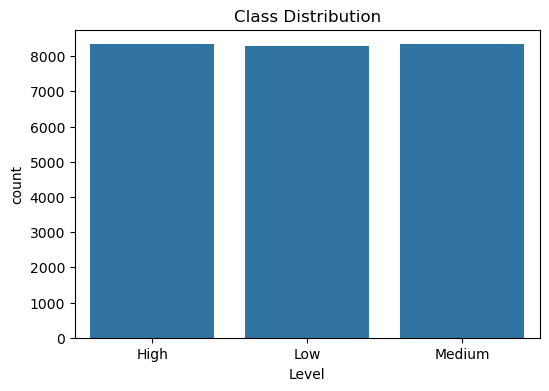

In [17]:
# class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Level', data=df)
plt.title("Class Distribution")
plt.show()

Shows number of samples in each class

Helps check if dataset is balanced

Classes:

Low

Medium

High

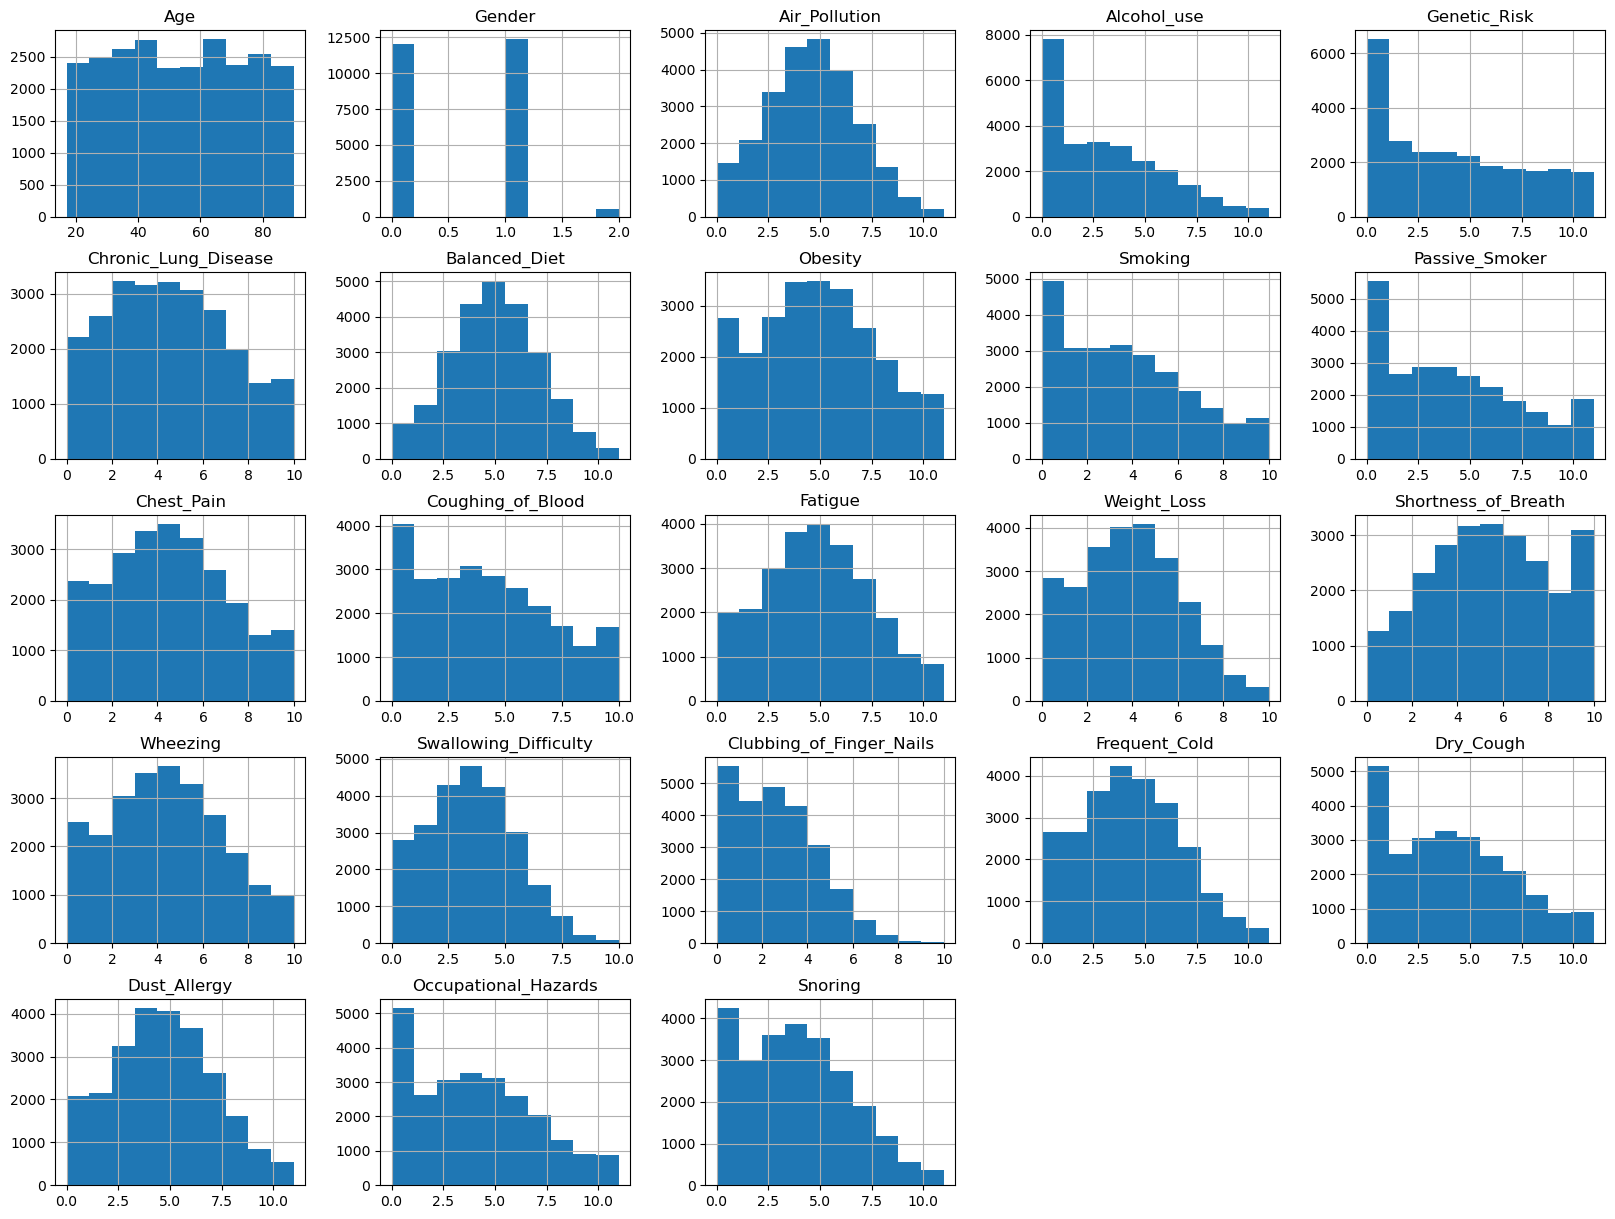

In [18]:
# Feature Distribution
df.hist(figsize=(20,15))
plt.show()

This creates histograms for all features.

Histograms show how values are distributed.

## Correlation Heatmap

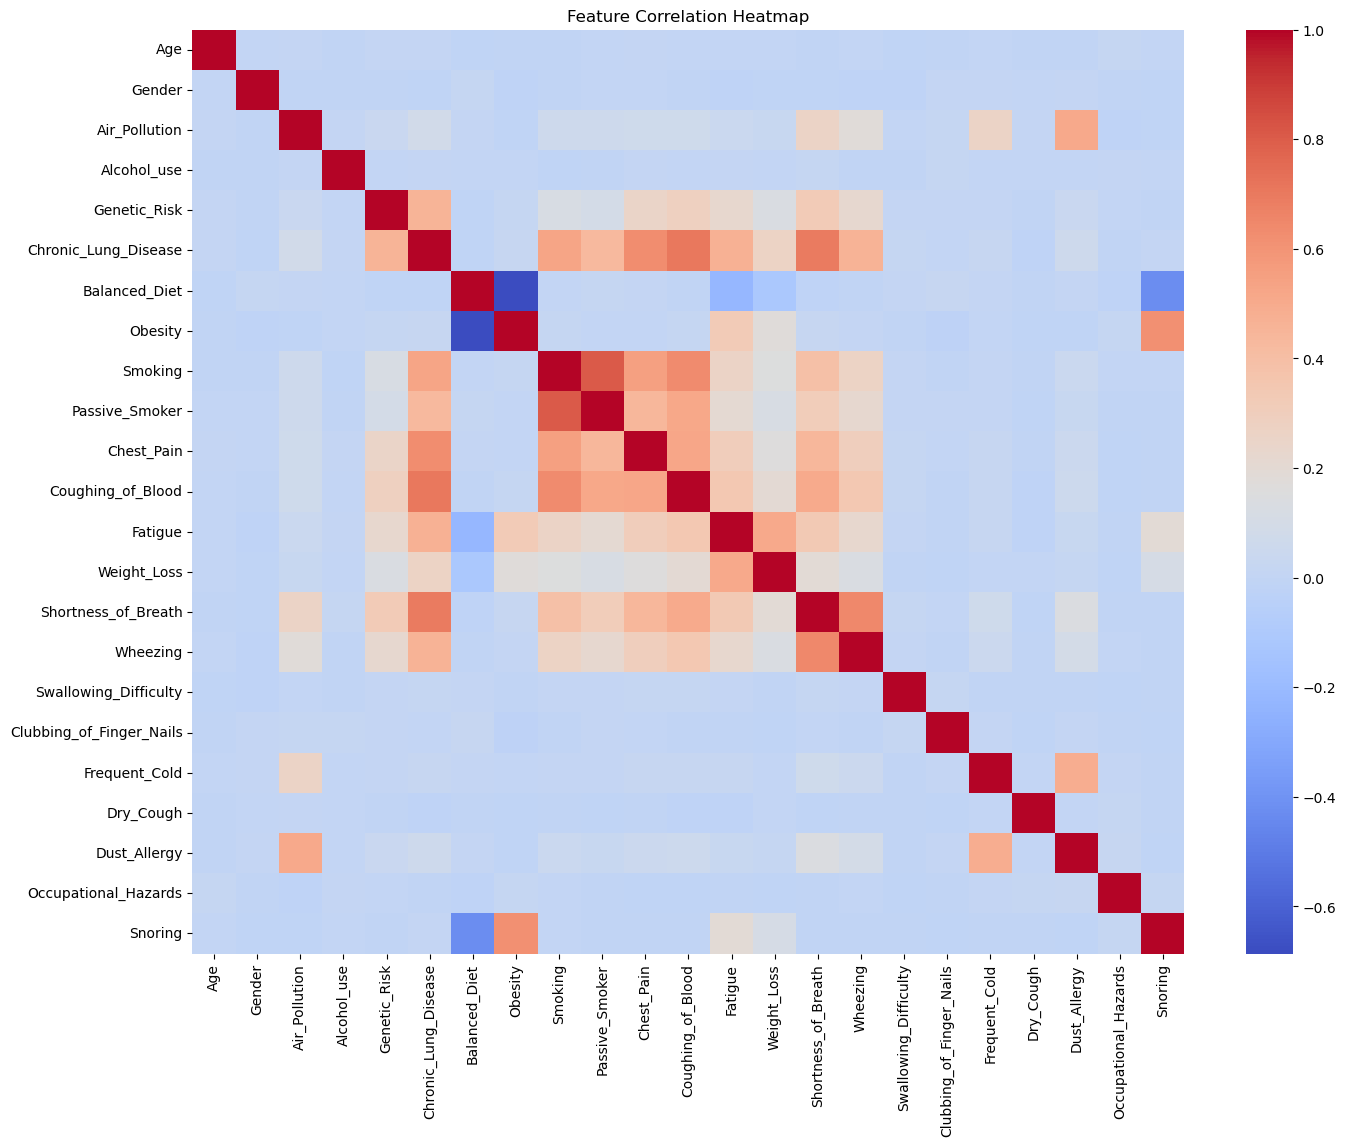

In [19]:
plt.figure(figsize=(16,12))

corr = df.drop(columns=['Level']).corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

A Correlation Heatmap is a graphical way to show the relationship between different features in a dataset.

What Correlation Means

Correlation tells how strongly two variables are related.

+1 → Strong positive relationship

0 → No relationship

-1 → Strong negative relationship

In [20]:
df_encoded = df.copy()

df_encoded['Level'] = df_encoded['Level'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

corr_target = df_encoded.corr()['Level'].sort_values(ascending=False)

print(corr_target)

Level                       1.000000
Chronic_Lung_Disease        0.791812
Shortness_of_Breath         0.719130
Coughing_of_Blood           0.717107
Smoking                     0.601430
Chest_Pain                  0.553125
Wheezing                    0.543231
Passive_Smoker              0.493829
Fatigue                     0.482018
Genetic_Risk                0.471662
Weight_Loss                 0.326969
Air_Pollution               0.265699
Dust_Allergy                0.197345
Frequent_Cold               0.086675
Obesity                     0.053033
Snoring                     0.018040
Swallowing_Difficulty       0.015811
Age                         0.005389
Alcohol_use                 0.003535
Occupational_Hazards       -0.003974
Clubbing_of_Finger_Nails   -0.004758
Dry_Cough                  -0.010963
Gender                     -0.015292
Balanced_Diet              -0.033489
Name: Level, dtype: float64


Machine learning models cannot work with text labels.

So the target variable is converted to numbers:

In [21]:
df['Level'] = df['Level'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

In [22]:
X = df.drop(columns=['Level'])
y = df['Level']

In [23]:
X

,Age,Gender,Air_Pollution,Alcohol_use,Genetic_Risk,Chronic_Lung_Disease,Balanced_Diet,Obesity,Smoking,Passive_Smoker,...,Weight_Loss,Shortness_of_Breath,Wheezing,Swallowing_Difficulty,Clubbing_of_Finger_Nails,Frequent_Cold,Dry_Cough,Dust_Allergy,Occupational_Hazards,Snoring
0,40.0,1,5.0,2.0,6.0,4.0,4.0,6.0,4.0,10.0,...,8.0,7.0,5.0,4.0,3.0,6.0,2.0,5.0,6.0,3.0
1,87.0,1,3.0,6.0,1.0,4.0,4.0,8.0,0.0,1.0,...,1.0,4.0,3.0,4.0,0.0,5.0,5.0,3.0,0.0,6.0
2,21.0,0,7.0,8.0,5.0,5.0,7.0,4.0,0.0,4.0,...,0.0,6.0,2.0,1.0,0.0,8.0,3.0,4.0,9.0,5.0
3,57.0,0,7.0,4.0,6.0,3.0,7.0,3.0,3.0,2.0,...,3.0,3.0,2.0,2.0,2.0,2.0,5.0,7.0,1.0,2.0
4,27.0,1,7.0,2.0,6.0,3.0,3.0,10.0,3.0,1.0,...,3.0,7.0,4.0,4.0,2.0,3.0,0.0,1.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,55.0,1,0.0,0.0,2.0,0.0,6.0,4.0,2.0,4.0,...,2.0,2.0,2.0,4.0,6.0,3.0,4.0,3.0,0.0,1.0
24996,74.0,1,6.0,4.0,10.0,7.0,8.0,0.0,4.0,4.0,...,2.0,7.0,4.0,2.0,1.0,2.0,7.0,5.0,5.0,4.0
24997,50.0,0,8.0,9.0,9.0,10.0,5.0,8.0,8.0,10.0,...,5.0,8.0,5.0,0.0,2.0,8.0,7.0,6.0,7.0,2.0
24998,86.0,0,4.0,2.0,8.0,5.0,8.0,0.0,0.0,1.0,...,3.0,3.0,1.0,4.0,4.0,6.0,3.0,6.0,2.0,4.0


In [24]:
y

0        2
1        0
2        1
3        1
4        1
        ..
24995    0
24996    2
24997    2
24998    1
24999    0
Name: Level, Length: 24948, dtype: int64

## Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Dataset split into:

80% training data

20% testing data

Parameters:

test_size=0.2 → 20% testing

stratify=y → keeps class distribution balanced

random_state=42 → ensures reproducibility

## Model Training

#### Logistic Regression

A basic machine learning algorithm used for classification problems.

It is simple and fast.

Works well when the relationship between features and target is linear.

Gives a baseline performance to compare with other models.

##### Used as the first model to check basic prediction performance for lung cancer risk.

In [26]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.894188376753507
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1656
           1       0.85      0.83      0.84      1667
           2       0.93      0.92      0.93      1667

    accuracy                           0.89      4990
   macro avg       0.89      0.89      0.89      4990
weighted avg       0.89      0.89      0.89      4990



#### Decision Tree

A model that makes predictions using a tree-like structure of decisions.

Easy to understand and visualize.

Works well with non-linear relationships.

Can automatically find important features.

##### Helps identify which symptoms or factors lead to higher cancer ris

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8210420841683367
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1656
           1       0.75      0.70      0.72      1667
           2       0.83      0.85      0.84      1667

    accuracy                           0.82      4990
   macro avg       0.82      0.82      0.82      4990
weighted avg       0.82      0.82      0.82      4990



#### Random Forest

An advanced model that combines many decision trees.

Produces more accurate and stable predictions.

Reduces overfitting compared to a single decision tree.

Handles large datasets and many features well.

##### Used as the main model because it usually gives the highest accuracy.

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=4,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9094188376753507
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1656
           1       0.88      0.84      0.86      1667
           2       0.93      0.91      0.92      1667

    accuracy                           0.91      4990
   macro avg       0.91      0.91      0.91      4990
weighted avg       0.91      0.91      0.91      4990



#### Gradient Boosting

A boosting algorithm that builds trees sequentially, improving mistakes from previous trees.

Provides very strong prediction performance.

Learns complex relationships in data.

##### Used to see if boosting models can improve prediction accuracy compared to Random Forest.

In [29]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8869739478957915
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1656
           1       0.84      0.81      0.83      1667
           2       0.92      0.91      0.92      1667

    accuracy                           0.89      4990
   macro avg       0.89      0.89      0.89      4990
weighted avg       0.89      0.89      0.89      4990



#### support Vector Machine (SVM)
A model that separates data using the best boundary (hyperplane).

Works well for classification problems with clear boundaries.

Effective in high-dimensional datasets.

Used to test if lung cancer risk categories can be separated using optimal decision boundaries.

In [30]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.895190380761523
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1656
           1       0.86      0.81      0.84      1667
           2       0.93      0.92      0.93      1667

    accuracy                           0.90      4990
   macro avg       0.89      0.90      0.89      4990
weighted avg       0.89      0.90      0.89      4990



In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling means bringing all features to the same range.

Prevents large features dominating small ones

Improves model performance

## Compare All Model Accuracies

Testing multiple ML models and comparing their performance.

In [32]:
results = {

"Logistic Regression": accuracy_score(y_test, y_pred_log),
"Decision Tree": accuracy_score(y_test, y_pred_dt),
"Random Forest": accuracy_score(y_test, y_pred_rf),
"Gradient Boosting": accuracy_score(y_test, y_pred_gb),
"SVM": accuracy_score(y_test, y_pred_svm)

}

results_df = pd.DataFrame(list(results.items()), columns=["Model","Accuracy"])

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
2        Random Forest  0.909419
4                  SVM  0.895190
0  Logistic Regression  0.894188
3    Gradient Boosting  0.886974
1        Decision Tree  0.821042


In [33]:
best_model = rf_model

In [34]:
y_pred = best_model.predict(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [35]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Chronic_Lung_Disease        0.187012
Shortness_of_Breath         0.130318
Coughing_of_Blood           0.115969
Smoking                     0.076190
Genetic_Risk                0.062021
Wheezing                    0.054063
Fatigue                     0.041331
Chest_Pain                  0.039961
Air_Pollution               0.037638
Passive_Smoker              0.036056
Weight_Loss                 0.029320
Dust_Allergy                0.026108
Age                         0.023562
Frequent_Cold               0.016423
Dry_Cough                   0.015934
Occupational_Hazards        0.015793
Snoring                     0.015382
Alcohol_use                 0.015270
Obesity                     0.015261
Balanced_Diet               0.014095
Swallowing_Difficulty       0.014081
Clubbing_of_Finger_Nails    0.013041
Gender                      0.005169
dtype: float64


This cell extracts and sorts the feature importance scores from the Random Forest model to identify which features have the greatest impact on lung cancer prediction.

## Confusion Matrix

A table used to evaluate classification model performance.
Accuracy alone is not enough.

Confusion matrix shows values like:

False positives

False negatives

True positive 

True negative 

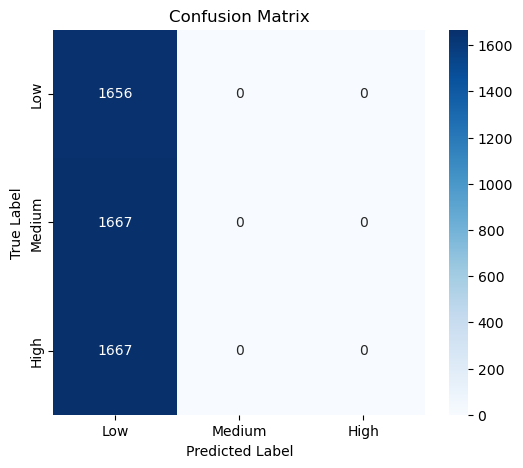

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50      1656
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1667

    accuracy                           0.33      4990
   macro avg       0.11      0.33      0.17      4990
weighted avg       0.11      0.33      0.17      4990



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({

'Feature': X.columns,
'Importance': importance

}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                     Feature  Importance
5       Chronic_Lung_Disease    0.187012
14       Shortness_of_Breath    0.130318
11         Coughing_of_Blood    0.115969
8                    Smoking    0.076190
4               Genetic_Risk    0.062021
15                  Wheezing    0.054063
12                   Fatigue    0.041331
10                Chest_Pain    0.039961
2              Air_Pollution    0.037638
9             Passive_Smoker    0.036056
13               Weight_Loss    0.029320
20              Dust_Allergy    0.026108
0                        Age    0.023562
18             Frequent_Cold    0.016423
19                 Dry_Cough    0.015934
21      Occupational_Hazards    0.015793
22                   Snoring    0.015382
3                Alcohol_use    0.015270
7                    Obesity    0.015261
6              Balanced_Diet    0.014095
16     Swallowing_Difficulty    0.014081
17  Clubbing_of_Finger_Nails    0.013041
1                     Gender    0.005169


This cell extracts feature importance from the trained model, creates a sorted table of features and their importance scores, and shows which factors contribute most to the lung cancer prediction model.

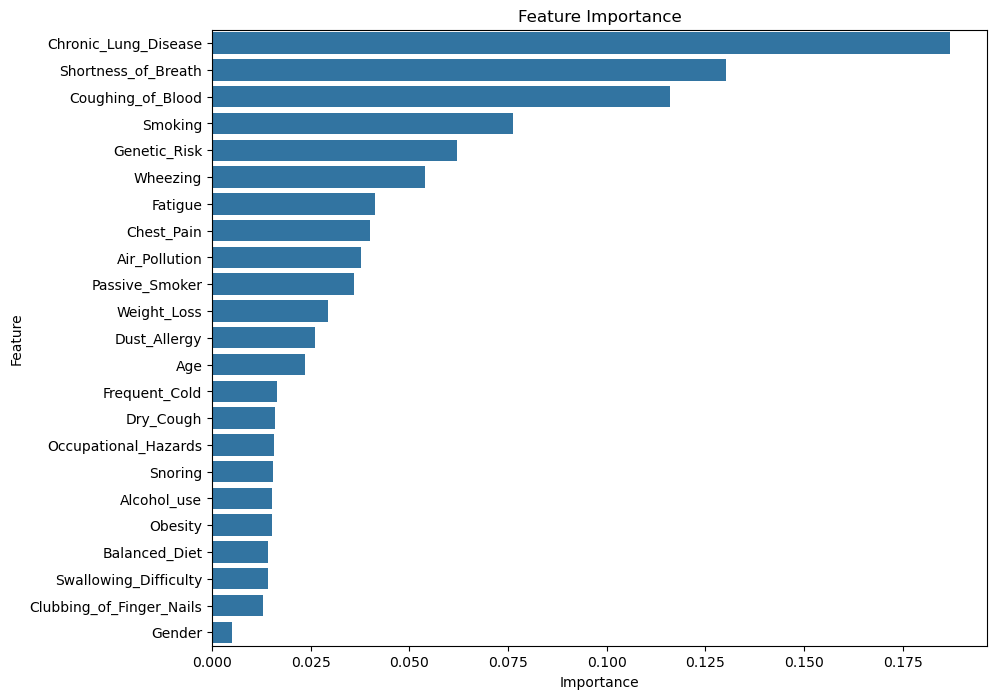

In [39]:
plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

This cell creates a bar chart that visually shows which features are most important in predicting lung cancer risk

In [40]:
def predict_lung_cancer(data):

    prediction = best_model.predict([data])[0]

    if prediction == 0:
        return "Low Risk"

    elif prediction == 1:
        return "Medium Risk"

    else:
        return "High Risk"

This function takes input data, uses the trained machine learning model to predict lung cancer risk, and converts the numerical prediction into a readable risk level such as Low, Medium, or High.

In [41]:

joblib.dump(best_model, "lung_cancer_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


This cell saves the trained machine learning model into a .pkl file using joblib so it can be loaded later and used for prediction without retraining the model.